# GW waveform and Basic parameter estimation Tutorial

This is a notebook to follow along for the *"PE and waveform generation"* session.

Link to the slide: [Google Drive](https://drive.google.com/file/d/1oNofzqlbfmuXGQM1ULfUgetWfH-7EiJb/view?usp=sharing)

In [6]:
# Basic imports
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# For disabling LALSuirte warning messages
import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")

# Import bilby and gwpy
from bilby import run_sampler
from bilby.core.utils import logger, create_time_series
from bilby.core.prior import Uniform, Cosine
from bilby.gw.waveform_generator import WaveformGenerator
from bilby.gw.detector import InterferometerList, PowerSpectralDensity
from bilby.gw.source import lal_binary_black_hole
from bilby.gw.conversion import \
    convert_to_lal_binary_black_hole_parameters, generate_all_bbh_parameters
from bilby.gw.prior import BBHPriorDict
from bilby.gw.likelihood import GravitationalWaveTransient
from bilby.gw.result import CBCResult
from gwpy.timeseries import TimeSeries
from pesummary.io import read

from extrinsic_likelihood import SimpleExtrinsicGWTransient

# Update plt plotting style
# Has to be after the gwpy import (otherwise would be overwritten)
plt.style.use("../matplotlibrc")

outdir = Path('./figures')
outdir.mkdir(exist_ok=True)

## Gravitational waves waveform

In this section, we first have a look at how to generate a GW waveform using the standard analysis package employed in LIGO –– `Bilby`.

We will also look at how different binary parameters would affect the waveform morphologies. 

Then, we will explore how different waveform models, constructed from several different physical foundations, would affect some details in the waveforms. 
Especically when it comes to more asymmetric binaries.

In [7]:
duration = 4.0  # s
sampling_frequency = 4096.0  # Hz
minimum_frequency = 20.0  # Hz
reference_frequency = 50.0  # Hz
geocent_time = 1126259462.4  # s

# Parameters of the first GW signal –– GW150914
gw150914_parameters = dict(
    total_mass=66.0,
    mass_ratio=30.0/35.0,
    a_1=0.4,
    a_2=0.3,
    tilt_1=0.5,
    tilt_2=1.0,
    phi_12=1.7,
    phi_jl=0.3,
    luminosity_distance=470.0,
    theta_jn=0.4,
    psi=2.65,
    phase=1.3,
    geocent_time=geocent_time,
    ra=1.375,
    dec=-1.2108,
)

# waveform generator
wfm_gen = WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=lal_binary_black_hole,
    parameter_conversion=convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=dict(
        waveform_approximant="IMRPhenomXPHM",
        reference_frequency=reference_frequency
    ),
)

21:04 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


### Effect of changing different binary parameters on the waveform

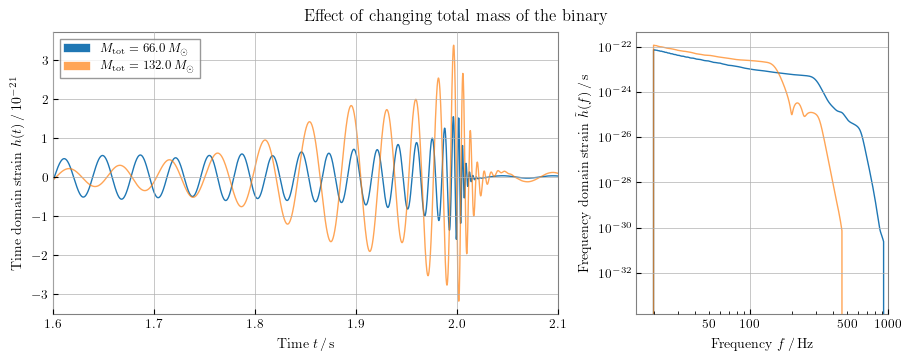

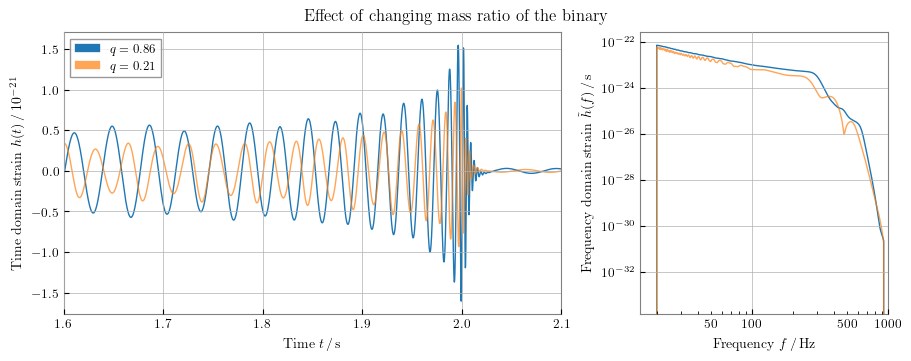

In [8]:
wfm_gen.parameters = gw150914_parameters

gw_strain_td = wfm_gen.time_domain_strain()['plus']
gw_strain_fd = wfm_gen.frequency_domain_strain()['plus']

fig1, axes1 = plt.subplots(1, 2, figsize=(9, 3.5),
                         width_ratios=[2, 1], constrained_layout=True)
fig1.suptitle('Effect of changing total mass of the binary')
fig2, axes2 = plt.subplots(1, 2, figsize=(9, 3.5),
                         width_ratios=[2, 1], constrained_layout=True)
fig2.suptitle('Effect of changing mass ratio of the binary')

# Plot the original waveform first
for axes in (axes1, axes2):
    ## Time-domain
    ax = axes[0]
    ax.plot(wfm_gen.time_array,
            np.roll(gw_strain_td, int(duration * sampling_frequency/2)) * 1e21)
    ax.set_xlabel(r'Time $t\,/\,{\rm s}$')
    ax.set_ylabel(r'Time domain strain $h(t)\,/\,10^{-21}$')
    ## Frequency-domain
    ax = axes[1]
    ax.loglog(wfm_gen.frequency_array, np.abs(gw_strain_fd))
    ax.set_xlabel(r'Frequency $f\,/\,{\rm Hz}$')
    ax.set_ylabel(r'Frequency domain strain $\tilde h(f)\,/\,{\rm s}$')

    axes[0].set_xlim(1.6, 2.1)
    axes[1].set_xlim(15, 1000)

## Varying the parameters
### Update masses
axes = axes1
massive_bbh = gw150914_parameters.copy()
massive_bbh['total_mass'] *= 2.0  # 66 * 2 = 132
wfm_gen.parameters = massive_bbh
gw_strain_td = wfm_gen.time_domain_strain()['plus']
gw_strain_fd = wfm_gen.frequency_domain_strain()['plus']

ax = axes[0]
ax.plot(wfm_gen.time_array,
        np.roll(gw_strain_td, int(duration * sampling_frequency/2)) * 1e21,
        alpha=0.7)
ax.legend(labels=[
    fr'$M_{{\rm tot}} = {gw150914_parameters["total_mass"]:.1f}\,M_\odot$',
    fr'$M_{{\rm tot}} = {massive_bbh["total_mass"]:.1f}\,M_\odot$'])
ax = axes[1]
ax.loglog(wfm_gen.frequency_array, np.abs(gw_strain_fd), alpha=0.7)


### Update the mass ratio.
axes = axes2
asymmetric_bbh = gw150914_parameters.copy()
asymmetric_bbh['mass_ratio'] /= 4.0
wfm_gen.parameters = asymmetric_bbh
gw_strain_td = wfm_gen.time_domain_strain()['plus']
gw_strain_fd = wfm_gen.frequency_domain_strain()['plus']

ax = axes[0]
ax.plot(wfm_gen.time_array,
        np.roll(gw_strain_td, int(duration * sampling_frequency/2)) * 1e21,
        alpha=0.7)
ax.legend(labels=[
    fr'$q = {gw150914_parameters["mass_ratio"]:.2f}$',
    fr'$q = {asymmetric_bbh["mass_ratio"]:.2f}$'])
ax = axes[1]
ax.loglog(wfm_gen.frequency_array, np.abs(gw_strain_fd), alpha=0.7)

fig1.savefig(outdir / 'effect_of_total_mass_on_waveform.pdf')
fig2.savefig(outdir / 'effect_of_mass_ratio_on_waveform.pdf')

## Gravitational wave strain data
<!--
## Noise on detector data and models on generated waveform

In [9]:
# Initialise a detector network
ifos = InterferometerList(['H1', 'L1', 'V1'])

O4_sens = ('aLIGO_O4_high_asd.txt', 'AdV_asd.txt')
gen3_sens = ('CE_wb_asd.txt', 'ET_D_asd.txt')

set_strain_kwargs = dict(sampling_frequency=sampling_frequency, duration=duration, start_time=geocent_time - 2)
inject_kwargs = dict(waveform_generator=wfm_gen, parameters=gw150914_parameters)

wh_strains_dict = {}

def save_to_dict(name, ifos, strain_dict=wh_strains_dict):
    strain_dict[f'{name}_td'] = {ifo.name: ifo.whitened_time_domain_strain for ifo in ifos}
    strain_dict[f'{name}_fd'] = {ifo.name: ifo.whitened_frequency_domain_strain for ifo in ifos}
    strain_dict[f'{name}_opt_snr'] = np.sqrt(np.sum([ifo.meta_data['optimal_SNR']**2 for ifo in ifos]))
    strain_dict[f'{name}_mf_snr'] = np.sqrt(np.sum([ifo.meta_data['matched_filter_SNR']**2 for ifo in ifos]))

for name, sens in zip(
    ('o4', '3gen'), (O4_sens, gen3_sens)
):
    for ifo in ifos:
        if ifo.name == 'V1':
            ifo.power_spectral_density = PowerSpectralDensity(asd_file=sens[1])
        else:
            ifo.power_spectral_density = PowerSpectralDensity(asd_file=sens[0])

    # Zero-noise
    ifos.set_strain_data_from_zero_noise(**set_strain_kwargs)
    ifos.inject_signal(**inject_kwargs)
    save_to_dict(name+'_zn', ifos)

    ## Clear the stored strain data
    ifos.set_strain_data_from_zero_noise(**set_strain_kwargs)
    ifos.set_strain_data_from_power_spectral_densities(**set_strain_kwargs)
    ifos.inject_signal(**inject_kwargs)
    save_to_dict(name, ifos)


21:05 bilby INFO    : Injected signal in H1:
21:05 bilby INFO    :   optimal SNR = 53.14
21:05 bilby INFO    :   matched filter SNR = 53.14+0.00j
21:05 bilby INFO    :   total_mass = 66.0
21:05 bilby INFO    :   mass_ratio = 0.8571428571428571
21:05 bilby INFO    :   a_1 = 0.4
21:05 bilby INFO    :   a_2 = 0.3
21:05 bilby INFO    :   tilt_1 = 0.5
21:05 bilby INFO    :   tilt_2 = 1.0
21:05 bilby INFO    :   phi_12 = 1.7
21:05 bilby INFO    :   phi_jl = 0.3
21:05 bilby INFO    :   luminosity_distance = 470.0
21:05 bilby INFO    :   theta_jn = 0.4
21:05 bilby INFO    :   psi = 2.65
21:05 bilby INFO    :   phase = 1.3
21:05 bilby INFO    :   geocent_time = 1126259462.4
21:05 bilby INFO    :   ra = 1.375
21:05 bilby INFO    :   dec = -1.2108
21:05 bilby INFO    : Injected signal in L1:
21:05 bilby INFO    :   optimal SNR = 42.97
21:05 bilby INFO    :   matched filter SNR = 42.97-0.00j
21:05 bilby INFO    :   total_mass = 66.0
21:05 bilby INFO    :   mass_ratio = 0.8571428571428571
21:05 bil

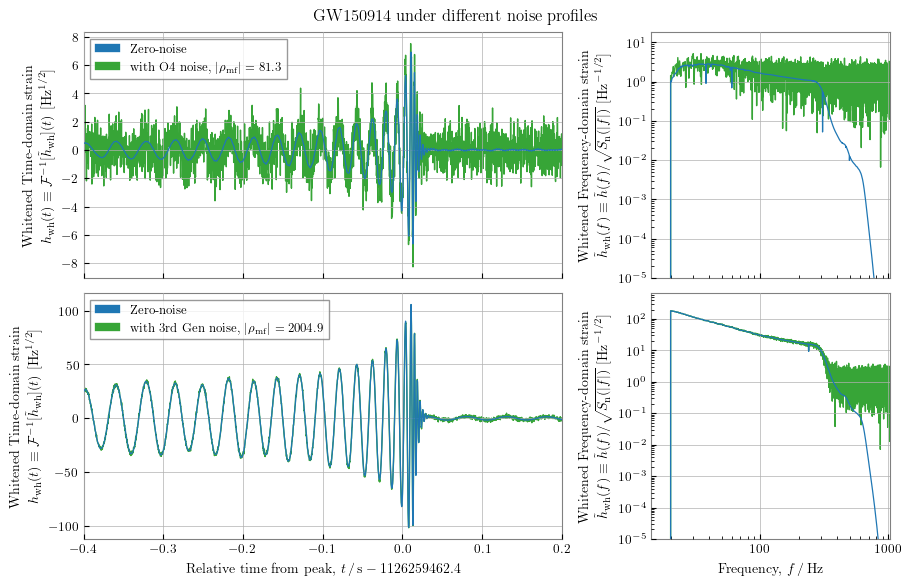

In [10]:
fig, Axes = plt.subplots(2, 2, figsize=(9, 5.75), sharex='col',
                         width_ratios=[2, 1], constrained_layout=True)

zn_kwargs = {'lw': 0.9, 'zorder': 10, 'label': 'Zero-noise'}

for axes, name, label in zip(Axes, ('o4', '3gen'), ('O4', '3rd Gen')):
    ax = axes[0]
    ax.plot(ifos[0].time_array - geocent_time, wh_strains_dict[f'{name}_zn_td']['H1'], **zn_kwargs)
    ax.plot(ifos[0].time_array - geocent_time, wh_strains_dict[f'{name}_td']['H1'],
            label=fr'with {label} noise, $|\rho_{{\rm mf}}| = {np.abs(wh_strains_dict[f"{name}_mf_snr"]):.1f}$',
            alpha=.95, c='C2')
    ax.legend()
    ax = axes[1]
    ax.loglog(ifos[1].frequency_array, np.abs(wh_strains_dict[f'{name}_zn_fd']['H1']), **zn_kwargs)
    ax.loglog(ifos[1].frequency_array, np.abs(wh_strains_dict[f'{name}_fd']['H1']),
              alpha=.95, c='C2')

for ax in Axes[:, 0]:
    ax.set_ylabel("Whitened Time-domain strain\n" + r'$h_{\rm wh}(t) \equiv {\cal F}^{-1}[\tilde h_{\rm wh}](t)\ [{\rm Hz}^{1/2}]$')
    ax.set_xlim(-0.4, +0.2)
for ax in Axes[:, 1]:
    ax.set_ylabel("Whitened Frequency-domain strain\n" + r'$\tilde{h}_{\rm wh}(f) \equiv \tilde{h}(f)/\sqrt{S_{\rm n}(|f|)}\ [{\rm Hz}^{-1/2}]$')
    ax.set_xlim(14, 1024)
    ax.set_ylim(bottom=1e-5)

Axes[1, 0].set_xlabel(fr'Relative time from peak, $t\,/\,{{\rm s}} - {geocent_time:.1f}$')
Axes[1, 1].set_xlabel(r'Frequency, $f\,/\,{\rm Hz}$')
fig.suptitle('GW150914 under different noise profiles')
fig.savefig(outdir / 'different_noises.pdf')

## Interacting with posterior samples
<!--  Read poterior samples and plot distributions -->

In this section, we will have a look at the posterior samples of another famous event -- GW231123. 

This event was known for its being the most massive BHs (at the time) and therefore a relative short signal, making it a challenging task for the analysis.

We will use two different packages to interact with its samples:
* `bilby` -- the analysis package itself; and
* `pesummary` -- the package designed for interacting with and unifying posterior samples from different analysis pipelines.

In [11]:
## get data from google drive/GitHub
samples_indir = Path('/users/shared.user/Summer2026/SummerSchool2026')
full_result = CBCResult.from_hdf5(samples_indir / 'S231123cg_bilby_NRSur7dq4_merge_result.hdf5')

21:05 bilby INFO    : Global meta data was removed from the result object for compatibility. Use the `BILBY_INCLUDE_GLOBAL_METADATA` environment variable to include it. This behaviour will be removed in a future release. For more details see: https://bilby-dev.github.io/bilby/faq.html#global-meta-data


In [12]:
# This file may take a while to load.
published_result = read(samples_indir / "S231123cg_discovery_pesummary.hdf5", package='gw')

/opt/conda/envs/Summer2026-py311/lib/python3.11/site-packages/pycbc/inference/models/__init__.py:24: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import iter_entry_points as _iter_entry_points


lal.MSUN_SI != Msun


In [13]:
published_result.

SyntaxError: invalid syntax (779768339.py, line 1)

In [ ]:
fetch_open_samples(
 7    "GW190814", catalog="GWTC-2", read_file=False, delete_on_exit=False,
 8    outdir=".", unpack=True, path="GW190814.h5"
 9)

## Parameter estimation example
<!-- ## Perform simplified PE by bilby with given detector data

The Bayes' inference

$$
p(\theta \,|\, d) = \frac{{\cal L}(d \,|\, \theta)\,\pi(\theta)}{{\cal Z}(d)}
$$

where

* $p(\theta \,|\, d)$ is the posterior distribution of $\theta$
* ${\cal L}(d \,|\, \theta)$ is the likelihood function
* $\pi(\theta)$ is the prior distribution of the parameters (before the analysis)
* ${\cal Z}(d)$ is called the evidence of the data, under our assumption

The likelihood depends on the waveform model, $h(\theta)$, specifically, given parameters $\theta$, the likelihood reads
$$
{\cal L}(d \,|\, \theta) \propto \exp\left(-\frac{1}{2}\langle d - h(\theta)\,|\,d-h(\theta)\rangle\right)\ ,
$$
where $\langle \cdot \,|\, \cdot \rangle$ is called the noise-weighted inner product.

In a GW data analysis, the goal is to obtain the posterior distribution of the BBH parameters ($\theta$) and the evidence of $d$ being a genuine GW signal.

The evidence, as a normalisation constant (of $p(\theta\,|\,d)$), can be obtained through
$$
{\cal Z}(d) = \int {\rm d}\theta\, {\cal L}(d \,|\, \theta)\,\pi(\theta)\ ,
$$
also known as the marginalised likelihood. This is a high-dimensional integration, for precessing BBH it is 15. A traditional grid-base approach to integrate this would not be computationally feasible, hence most analyses rely on stochastic integration instead.

In `bilby`, one would need to
1. prepare the data, $d$ (in the interferometer object)
2. specify the waveform model to use ($h(\theta)$)
3. set the priors, $\pi(\theta)$
4. set up the likelihood from the data and the waveform model
5. run the sampling process as a means to perform integration.

**Important note**: The following cell will take at least 20 mins to complete, run with cautions.

In [16]:
# IO settings
label = 'GW150914_extrinsic_pe'
pe_outdir = Path('./outdir_' + label)
pe_outdir.mkdir(exist_ok=True)

# Data conditioning
trigger_time = 1126259462.4
sampling_frequency = 1024
maximum_frequency = 512
minimum_frequency = 20
roll_off = 0.4  # Roll off duration of tukey window in seconds, default is 0.4s
duration = 4  # Analysis segment duration
post_trigger_duration = 2  # Time between trigger time and end of segment
end_time = trigger_time + post_trigger_duration
start_time = end_time - duration

## for estimating PSD from adjacent data segments
psd_duration = 32 * duration
psd_start_time = start_time - psd_duration
psd_end_time = start_time

# # 1. Initialising detector network and strain data
# pe_ifos = InterferometerList(['H1', 'L1'])
# for ifo in pe_ifos:
#     det = ifo.name
#     logger.info(f"Downloading analysis data for {det}")
#     data = TimeSeries.fetch_open_data(det, start_time, end_time)
#     data = data.resample(sampling_frequency)
#     ifo.strain_data.set_from_gwpy_timeseries(data)

#     logger.info(f"Downloading psd data for {det}")
#     psd_data = TimeSeries.fetch_open_data(det, psd_start_time, psd_end_time)
#     psd = psd_data.psd(
#         fftlength=duration, overlap=0,
#         window=("tukey", 2 * roll_off / duration), method="median"
#     )
#     ifo.power_spectral_density = PowerSpectralDensity(
#         frequency_array=psd.frequencies.value, psd_array=psd.value
#     )
#     ifo.maximum_frequency = maximum_frequency
#     ifo.minimum_frequency = minimum_frequency

# logger.info(f"Saving data plots to {pe_outdir}")
# pe_ifos.plot_data(outdir=pe_outdir, label=label)
pe_ifos = ifos

# 2. Initialise the waveform generator (with IMRPhenomPv2)
wfm_gen = WaveformGenerator(
    frequency_domain_source_model=lal_binary_black_hole,
    parameter_conversion=convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=dict(
        waveform_approximant="IMRPhenomPv2",
        reference_frequency=reference_frequency
    ),
)

# 3. Prepare the priors use in PE
## In this simple PE example, we sample only three parameters, the sky locations
## and time. Hence, we create the prior dictionary from the injection parameters instead.
prior_dict = gw150914_parameters.copy()
prior_dict.update(
    {
        'ra': Uniform(0, np.pi, name='ra'),
        'dec': Cosine(name='dec'),
        'geocent_time': Uniform(trigger_time-0.1, trigger_time+0.1, name='geocent_time')
    }
)
priors = BBHPriorDict(prior_dict)

# 4. Initialise the GW likelihood
likelihood = GravitationalWaveTransient(pe_ifos, wfm_gen, priors=priors)

# # # 5. Start the sampling process
# simple_pe_result = run_sampler(
#     likelihood, 
#     priors, sampler='dynesty',
#     outdir=pe_outdir, label=label,
#     nlive=512, npool=1,
#     conversion_function=generate_all_bbh_parameters,
#     result_class=CBCResult
# )
# simple_pe_result.plot_corner()

21:50 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


## Even faster

In the previous example, for each likelihood evaluation, a new GW waveform needs to be re-computed. 

However, if we are to vary only the extrinsic parameters, we don't need to invoke the waveform generation at every step, which is also the most computationally expensive step.

Recall that the GW is given by:
$$
\tilde h(f; \Xi, \alpha, \delta, \psi, d_{\rm L}, t'_{\rm c}) = \frac{1}{d_{\rm L}} \left[ F_+(\alpha,\delta,\psi,t'_{\rm c})\,\tilde{h}_+(f;\Xi) + F_\times(\alpha,\delta,\psi,t'_{\rm c})\,\tilde{h}_\times(f;\Xi) \right] \,\exp(-{\rm i}2\pi f (t'_{\rm c} - t_{\rm c}))
$$
for which we will simply write
$$
\begin{equation}
\tilde h(f) = \frac{1}{d_{\rm L}} \left( F_+\,\tilde{h}_+(f) + F_\times\,\tilde{h}_\times(f) \right) \,\exp(-{\rm i}2\pi f \Delta t_{\rm c})
\end{equation}
$$

Going back to the GW likelihood:
$$
\begin{align*}
\ln{\cal L} &= -\frac{1}{2} \langle d - \tilde{h}(f), d- \tilde{h}(f) \rangle \\
&= -\frac{1}{2} \left [ \langle d, d\rangle - 2 \langle h, d \rangle + \langle h , h \rangle \right ]\\
\ln({\cal L}/{\cal L_0}) &=   \langle h, d \rangle - \frac{1}{2}\langle h , h \rangle  \\
\end{align*}
$$
As usual, ${\cal L}_0 = -\langle d,d\rangle / 2$ is the noise evidence, and ${\cal L}/{\cal L_0}$ is called the likelihood ratio.

Then we substitute the expanded form the GW waveform (Eq.1), then the two inner products become:
$$
\begin{align*}
\langle h, d \rangle &= \frac{1}{d_{\rm L}} \left[ F_+ \langle h_+\,{\rm e}^{-{\rm i}2\pi f \Delta t_{\rm c}}, d \rangle  +  F_\times \langle h_\times\,{\rm e}^{-{\rm i}2\pi f \Delta t_{\rm c}}, d \rangle \right ] \\
&= \frac{1}{d_{\rm L}} \left[ F_+ \,I_+^{h,d}(\Delta t_{\rm c})  +  F_\times\,I_\times^{h,d}(\Delta t_{\rm c})\right ] \\
\end{align*}
$$
Here, $I_{+,\times}^{h,d}(\Delta t_{\rm c}) = I_{+,\times}^{h,d}(t'_{\rm c} - t_{\rm c})$ are functions of different $t'_{\rm c}$, and they can can be precomputed and interpolated for the two polarisations.

Similarly, for the optimal SNR squared ($\langle h, h \rangle$), it can be expanded as:
$$
\begin{align*}
\langle h, h \rangle &= \frac{1}{d_{\rm L}^2} \left[ 
    F_+^2 \,\langle h_+\,{\rm e}^{-{\rm i}2\pi f \Delta t_{\rm c}},  h_+\,{\rm e}^{-{\rm i}2\pi f \Delta t_{\rm c}} \rangle  
    + 2\,F_+F_\times \,\langle h_+\,{\rm e}^{-{\rm i}2\pi f \Delta t_{\rm c}},  h_\times\,{\rm e}^{-{\rm i}2\pi f \Delta t_{\rm c}} \rangle  
    + F_\times^2 \,\langle h_\times\,{\rm e}^{-{\rm i}2\pi f \Delta t_{\rm c}},  h_\times\,{\rm e}^{-{\rm i}2\pi f \Delta t_{\rm c}} \rangle  
    \right] \\
    &= \frac{1}{d_{\rm L}^2} \left[ 
    F_+^2 \,\langle h_+,  h_+ \rangle  
    + 2\,F_+F_\times \,\langle h_+,  h_\times \rangle  
    + F_\times^2 \,\langle h_\times,  h_\times \rangle  
    \right] \\
    &= \frac{1}{d_{\rm L}^2} 
    \left[ 
    F_+^2 \,I_{(+,+)} + 2\,F_+F_\times \, I_{(+,\times)} + F_\times^2 \,I_{(\times,\times)}
    \right]
\end{align*}
$$
Going from the first to second line, we make use of the fact the phase factor would be cancelled when taking the conjugate.
Here, $I_{(+,+)},\, I_{(+,\times)},\,I_{(\times,\times)}$ are three constants that can be pre-computed. Essentially, these the SNRs of the plus and cross polarisations, and their overlap.

Ultimately, stitching everything together, we have converted the likelihood ratio into the following:
$$
\ln({\cal L}/{\cal L_0}) =  \frac{1}{{\color{red}d_{\rm L}}} \left\{\left[ {\color{red}F_+} \,I_+^{h,d}(\Delta t_{\rm c})  +  {\color{red}F_\times}\,I_\times^{h,d}(\Delta t_{\rm c})\right ]
- \frac{1}{2{\color{red}d_{\rm L}}} \left[ 
    {\color{red}F_+^2} \,I_{(+,+)} + 2\,{\color{red}F_+F_\times} \, I_{(+,\times)} + {\color{red}F_\times^2} \,I_{(\times,\times)}
    \right]
 \right\}
$$
coloured in red are the only components that needs to be recomputed at each iteration, which are all much simpler functions to be evaluated, making the overall sampling process immensely faster.

With the much simplified likelihood function, in the following example, we will perform the same analysis.

Not only that, we will also include two more parameters to vary, and it will still run faster than the previous example.

In [17]:
from copy import deepcopy 

# IO settings
label = 'GW150914_quick_ext_pe'
pe_outdir = Path('./outdir_' + label)
pe_outdir.mkdir(exist_ok=True)

extrinsic_priors = deepcopy(priors)
extrinsic_priors['luminosity_distance'] = Uniform(100, 2000, name='luminosity_distance')
extrinsic_priors['psi'] = Uniform(0, np.pi, name='psi')

# 4. Initialise the GW likelihood
ext_likelihood = SimpleExtrinsicGWTransient(ifos, wfm_gen, priors=extrinsic_priors, 
                                            intrinsic_parameters=gw150914_parameters)

# # 5. Start the sampling process
simple_pe_result = run_sampler(
    ext_likelihood,
    priors, sampler='dynesty',
    outdir=pe_outdir, label=label,
    nlive=512, npool=1,
    conversion_function=generate_all_bbh_parameters,
    result_class=CBCResult
)
simple_pe_result.plot_corner()

21:50 bilby INFO    : Running for label 'GW150914_quick_ext_pe', output will be saved to 'outdir_GW150914_quick_ext_pe'


21:51 bilby INFO    : Analysis priors:
21:51 bilby INFO    : geocent_time=Uniform(minimum=1126259462.3000002, maximum=1126259462.5, name='geocent_time', latex_label='$t_c$', unit=None, boundary=None)
21:51 bilby INFO    : ra=Uniform(minimum=0, maximum=3.141592653589793, name='ra', latex_label='$\\mathrm{RA}$', unit=None, boundary=None)
21:51 bilby INFO    : dec=Cosine(minimum=-1.5707963267948966, maximum=1.5707963267948966, name='dec', latex_label='$\\mathrm{DEC}$', unit=None, boundary=None)
21:51 bilby INFO    : total_mass=66.0
21:51 bilby INFO    : mass_ratio=0.8571428571428571
21:51 bilby INFO    : a_1=0.4
21:51 bilby INFO    : a_2=0.3
21:51 bilby INFO    : tilt_1=0.5
21:51 bilby INFO    : tilt_2=1.0
21:51 bilby INFO    : phi_12=1.7
21:51 bilby INFO    : phi_jl=0.3
21:51 bilby INFO    : luminosity_distance=470.0
21:51 bilby INFO    : theta_jn=0.4
21:51 bilby INFO    : psi=2.65
21:51 bilby INFO    : phase=1.3
21:51 bilby INFO    : Analysis likelihood class: <class 'extrinsic_likeliho

1it [00:00, ?it/s]

21:54 bilby INFO    : Run interrupted by signal 2: checkpoint and exit on 130
21:54 bilby INFO    : Written checkpoint file outdir_GW150914_quick_ext_pe/GW150914_quick_ext_pe_resume.pickle


SystemExit: 130

/opt/conda/envs/Summer2026-py311/lib/python3.11/site-packages/IPython/core/interactiveshell.py:3707: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


### Quick injection test

19:25 bilby INFO    : Waveform generator initiated with
  frequency_domain_source_model: bilby.gw.source.lal_binary_black_hole
  time_domain_source_model: None
  parameter_conversion: bilby.gw.conversion.convert_to_lal_binary_black_hole_parameters


19:25 bilby INFO    : Injected signal in H1:
19:25 bilby INFO    :   optimal SNR = 53.14
19:25 bilby INFO    :   matched filter SNR = 53.14+0.00j
19:25 bilby INFO    :   total_mass = 66.0
19:25 bilby INFO    :   mass_ratio = 0.8571428571428571
19:25 bilby INFO    :   a_1 = 0.4
19:25 bilby INFO    :   a_2 = 0.3
19:25 bilby INFO    :   tilt_1 = 0.5
19:25 bilby INFO    :   tilt_2 = 1.0
19:25 bilby INFO    :   phi_12 = 1.7
19:25 bilby INFO    :   phi_jl = 0.3
19:25 bilby INFO    :   luminosity_distance = 470.0
19:25 bilby INFO    :   theta_jn = 0.4
19:25 bilby INFO    :   psi = 2.65
19:25 bilby INFO    :   phase = 1.3
19:25 bilby INFO    :   geocent_time = 1126259462.4
19:25 bilby INFO    :   ra = 1.375
19:25 bilby INFO    :   dec = -1.2108
19:25 bilby INFO    : Injected signal in L1:
19:25 bilby INFO    :   optimal SNR = 42.97
19:25 bilby INFO    :   matched filter SNR = 42.97-0.00j
19:25 bilby INFO    :   total_mass = 66.0
19:25 bilby INFO    :   mass_ratio = 0.8571428571428571
19:25 bil

1it [00:00, ?it/s]

19:34 bilby INFO    : Written checkpoint file outdir_GW150914_simple_ext_pe_xphm/GW150914_simple_ext_pe_xphm_resume.pickle
/opt/conda/envs/Summer2026-py311/lib/python3.11/site-packages/dynesty/plotting.py:252: RuntimeWarning: overflow encountered in exp
  np.exp(logwt), logz if logplot else np.exp(logz)
/opt/conda/envs/Summer2026-py311/lib/python3.11/site-packages/dynesty/plotting.py:282: RuntimeWarning: overflow encountered in exp
  zspan = (0., 1.05 * np.exp(logz[-1] + 3. * logzerr[-1]))
19:34 bilby WARNING : Axis limits cannot be NaN or Inf
19:34 bilby WARNING : Failed to create dynesty run plot at checkpoint
19:34 bilby INFO    : Rejection sampling nested samples to obtain 1601 posterior samples
19:34 bilby INFO    : Sampling time: 0:09:14.115870
19:34 bilby INFO    : Computing per-detector log likelihoods.


  0%|          | 0/1601 [00:00<?, ?it/s]

19:34 bilby INFO    : Computing SNRs for every sample.


  0%|          | 0/1601 [00:00<?, ?it/s]

19:34 bilby INFO    : Summary of results:
nsamples: 1601
ln_noise_evidence: -2334.844
ln_evidence: -18.835 +/-  0.226
ln_bayes_factor: 2316.009 +/-  0.226



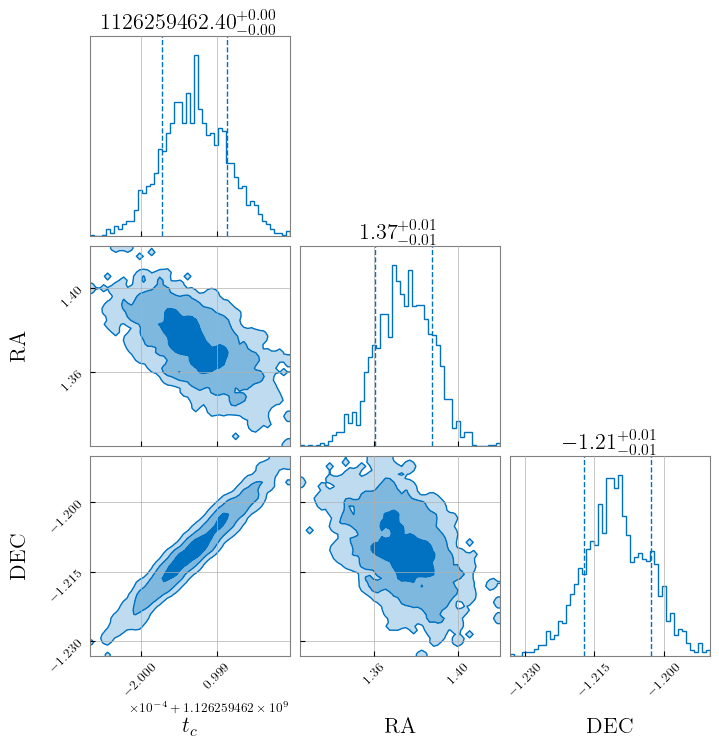

In [ ]:
# IO settings
label = 'Inj_quick_ext_pe_xphm'
pe_outdir = Path('./outdir_' + label)
pe_outdir.mkdir(exist_ok=True)

# Data conditioning
trigger_time = 1126259462.4
sampling_frequency = 1024
maximum_frequency = 512
minimum_frequency = 20

wfm_gen = WaveformGenerator(
    duration=duration, sampling_frequency=sampling_frequency,
    frequency_domain_source_model=lal_binary_black_hole,
    parameter_conversion=convert_to_lal_binary_black_hole_parameters,
    waveform_arguments=dict(
        waveform_approximant="IMRPhenomXPHM",
        reference_frequency=reference_frequency
    ),
)

set_strain_kwargs = dict(sampling_frequency=sampling_frequency, duration=duration, start_time=trigger_time - 2)
inject_kwargs = dict(waveform_generator=wfm_gen, parameters=gw150914_parameters)

ifos = InterferometerList(['H1', 'L1'])
for ifo in ifos:
    if ifo.name == 'V1':
        ifo.power_spectral_density = PowerSpectralDensity(asd_file=O4_sens[1])
    else:
        ifo.power_spectral_density = PowerSpectralDensity(asd_file=O4_sens[0])

# Zero-noise
ifos.set_strain_data_from_zero_noise(**set_strain_kwargs)
ifos.inject_signal(**inject_kwargs)

prior_dict = gw150914_parameters.copy()
prior_dict.update(
    {
        'ra': Uniform(0, np.pi, name='ra'),
        'dec': Cosine(name='dec'),
        'geocent_time': Uniform(trigger_time-0.1, trigger_time+0.1, name='geocent_time')
    }
)
priors = BBHPriorDict(prior_dict)

# 4. Initialise the GW likelihood
# likelihood = GravitationalWaveTransient(ifos, wfm_gen, priors=priors)
ext_likelihood = SimpleExtrinsicGWTransient(ifos, wfm_gen, priors=priors, 
                                            intrinsic_parameters=gw150914_parameters)

# # 5. Start the sampling process
simple_pe_result = run_sampler(
    # likelihood, 
    ext_likelihood,
    priors, sampler='dynesty',
    outdir=pe_outdir, label=label,
    nlive=512, npool=1,
    conversion_function=generate_all_bbh_parameters,
    result_class=CBCResult
)
simple_pe_result.plot_corner()